# Module 2: Supply-Chain Network and Chain-Leader Identification

**Streamlined M2-thesis version.**

Main chain:

$$
\text{Supplier}\rightarrow\text{Customer edges}
\rightarrow
\text{Out-Degree computation}
\rightarrow
\text{Top-5\% threshold}
\rightarrow
\text{Chain Leader }(0/1)
$$




## Cell 0 — Shared functions

Edge direction in the supplied network is:
$$
\text{supplier\_firm\_id} \rightarrow \text{customer\_firm\_id}.
$$




In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import networkx as nx

RANDOM_STATE = 42
TOP_PCT = 0.05

def load_firm_master(path="08_hybrid_firm_master_1500.csv"):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    return df

def load_supplier_edges(path="10_hybrid_supplier_customer_edges_6000.csv"):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    return df

def build_firm_graph(firm_df, edge_df):
    """Directed graph: supplier -> customer."""
    G = nx.DiGraph()
    for _, row in firm_df.iterrows():
        G.add_node(
            row["firm_id"],
            city=row.get("city", None),
            industry_code=row.get("industry_code", None),
        )
    for _, row in edge_df.iterrows():
        G.add_edge(
            row["supplier_firm_id"],
            row["customer_firm_id"],
            weight=float(row["relationship_weight"]),
        )
    return G

def centrality_diagnostics(G, firm_ids):
    """Centralities are diagnostic benchmarks; out_degree is the pre-specified primary score."""
    in_deg = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    weighted_out = dict(G.out_degree(weight="weight"))
    total_deg = dict(G.degree())
    pagerank = nx.pagerank(G, weight="weight", max_iter=500)
    betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)

    UG = nx.Graph(G)
    UG.remove_edges_from(nx.selfloop_edges(UG))
    k_core = nx.core_number(UG) if UG.number_of_nodes() else {}

    rows = []
    for fid in firm_ids:
        rows.append({
            "firm_id": fid,
            "in_degree": int(in_deg.get(fid, 0)),
            "out_degree": int(out_deg.get(fid, 0)),
            "weighted_out_degree": float(weighted_out.get(fid, 0.0)),
            "total_degree": int(total_deg.get(fid, 0)),
            "pagerank": float(pagerank.get(fid, 0.0)),
            "betweenness": float(betweenness.get(fid, 0.0)),
            "k_core": int(k_core.get(fid, 0)),
        })
    return pd.DataFrame(rows)

def exact_top_pct_flag(df, score_col, pct=TOP_PCT, out_col="is_chain_leader"):
    """Flag exactly ceil(N*pct) observations; firm_id is only a deterministic tie-breaker."""
    out = df.copy()
    n_top = int(np.ceil(len(out) * pct))
    ranked = out.sort_values(
        [score_col, "firm_id"],
        ascending=[False, True],
        kind="mergesort",
    )
    selected = set(ranked.head(n_top)["firm_id"])
    out[out_col] = out["firm_id"].isin(selected).astype(int)
    return out

def random_remove_edges(edge_df, remove_frac, seed):
    rng = np.random.default_rng(seed)
    keep_n = int(round(len(edge_df) * (1.0 - remove_frac)))
    keep_idx = rng.choice(edge_df.index.to_numpy(), size=keep_n, replace=False)
    return edge_df.loc[np.sort(keep_idx)].copy()


## Part A — Firm supply-chain network audit

This is the network actually used for chain-leader identification. The former industry-level IO network is no longer part of the main Module 2 workflow.


In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import networkx as nx

firms = load_firm_master()
edges = load_supplier_edges()

assert len(firms) == 1500, f"Expected 1500 firms, got {len(firms)}"
assert len(edges) == 6000, f"Expected 6000 edges, got {len(edges)}"

G = build_firm_graph(firms, edges)

audit = pd.DataFrame([{
    "n_firms": len(firms),
    "n_nodes": G.number_of_nodes(),
    "n_edges": G.number_of_edges(),
    "density": nx.density(G),
    "n_weak_components": nx.number_weakly_connected_components(G),
    "n_strong_components": nx.number_strongly_connected_components(G),
    "data_type": "SYNTHETIC_CALIBRATED_METHOD_VALIDATION",
}])
audit.to_csv("module2_firm_network_audit.csv", index=False, encoding="utf-8-sig")

print("=" * 90)
print("PART A - Firm supply-chain network audit")
print("=" * 90)
print(audit.to_string(index=False))
print("\nEdge direction: supplier -> customer")


PART A - Firm supply-chain network audit
 n_firms  n_nodes  n_edges  density  n_weak_components  n_strong_components                              data_type
    1500     1500     6000 0.002668                  6                  186 SYNTHETIC_CALIBRATED_METHOD_VALIDATION

Edge direction: supplier -> customer


## Part B — Centrality diagnostics and pre-specified chain-leader label

The primary chain-leader score is **out-degree** because, under the supplied edge direction, it directly counts downstream customer relationships.

Other centralities are computed only to answer a methodological question:

> Does a more complicated network centrality identify the latent core better than simple downstream reach?

They are **not** exported as Module 3 features.

Before any ground-truth file is loaded, the notebook creates:

\[
is\_chain\_leader_i = 1
\]

for the exact top 5% of firms by out-degree.


In [3]:
# -*- coding: utf-8 -*-
import pandas as pd

firms = load_firm_master()
edges = load_supplier_edges()
G = build_firm_graph(firms, edges)

centrality_df = centrality_diagnostics(G, firms["firm_id"].tolist())
centrality_df = centrality_df.merge(
    firms[["firm_id", "industry_code", "city"]],
    on="firm_id",
    how="left",
)

# IMPORTANT: this is created BEFORE ground truth is loaded.
centrality_df = exact_top_pct_flag(
    centrality_df,
    "out_degree",
    pct=TOP_PCT,
    out_col="is_chain_leader",
)

assert centrality_df["is_chain_leader"].sum() == 75
assert "latent_core_true" not in centrality_df.columns
assert "latent_core_propensity" not in centrality_df.columns

centrality_df.to_csv(
    "module2_firm_centrality_diagnostics.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 90)
print("PART B - Primary chain-leader construction")
print("=" * 90)
print(f"Firms flagged as chain leaders: {centrality_df['is_chain_leader'].sum()} / {len(centrality_df)}")
print("\nTop 15 firms by out-degree:")
print(
    centrality_df.sort_values(["out_degree", "firm_id"], ascending=[False, True])
    [["firm_id", "industry_code", "city", "out_degree", "weighted_out_degree", "is_chain_leader"]]
    .head(15)
    .to_string(index=False)
)
print("\nSaved: module2_firm_centrality_diagnostics.csv")


PART B - Primary chain-leader construction
Firms flagged as chain leaders: 75 / 1500

Top 15 firms by out-degree:
  firm_id industry_code city  out_degree  weighted_out_degree  is_chain_leader
SYNF00631           C34   成都          16           258.207885                1
SYNF01350           C30  攀枝花          14           210.520799                1
SYNF00050           C38   成都          13           278.374376                1
SYNF00148           C39   绵阳          13           303.545845                1
SYNF01173           C39   成都          13           281.327624                1
SYNF00240           C38   成都          12           229.846856                1
SYNF00251           C33   成都          12           208.416252                1
SYNF00410           C31   凉山          12           235.023409                1
SYNF00604           C27   成都          12           204.581234                1
SYNF00893           C26   成都          12           281.806826                1
SYNF01338        

### Out-degree distribution

The distribution gives a compact view of downstream customer reach across firms.


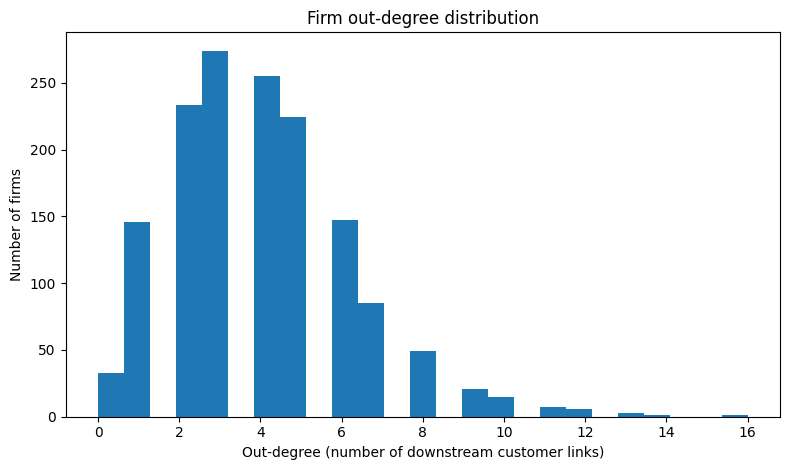

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(centrality_df["out_degree"], bins=25)
ax.set_xlabel("Out-degree (number of downstream customer links)")
ax.set_ylabel("Number of firms")
ax.set_title("Firm out-degree distribution")
plt.tight_layout()
plt.savefig("module2_fig1_out_degree_distribution.png", dpi=160)
plt.show()


## Part C — Evaluation-only validation against latent ground truth



The ground truth is used **only to evaluate** the already-defined network scores and chain-leader label. It is never used to construct edges, compute centralities, choose a threshold, or enter Module 3.


In [5]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

centrality_df = pd.read_csv(
    "module2_firm_centrality_diagnostics.csv",
    encoding="utf-8-sig",
)
ground_truth = pd.read_csv(
    "09_latent_core_ground_truth_EVALUATION_ONLY.csv",
    encoding="utf-8-sig",
)

eval_df = centrality_df.merge(
    ground_truth[["firm_id", "latent_core_true", "latent_core_propensity"]],
    on="firm_id",
    how="inner",
    validate="one_to_one",
)

candidate_methods = [
    "out_degree",
    "weighted_out_degree",
    "total_degree",
    "in_degree",
    "pagerank",
    "betweenness",
    "k_core",
]

rows = []
for method in candidate_methods:
    scored = exact_top_pct_flag(
        eval_df[["firm_id", method]].copy(),
        method,
        pct=TOP_PCT,
        out_col="pred_top5",
    )
    tmp = eval_df[["firm_id", "latent_core_true"]].merge(
        scored[["firm_id", "pred_top5"]],
        on="firm_id",
        how="left",
    )

    y_true = tmp["latent_core_true"].to_numpy(int)
    y_pred = tmp["pred_top5"].to_numpy(int)
    score = eval_df.set_index("firm_id").loc[tmp["firm_id"], method].to_numpy(float)

    rows.append({
        "method": method,
        "is_pre_specified_primary": method == "out_degree",
        "roc_auc": roc_auc_score(y_true, score),
        "average_precision": average_precision_score(y_true, score),
        "precision_at_exact_5pct": precision_score(y_true, y_pred, zero_division=0),
        "recall_at_exact_5pct": recall_score(y_true, y_pred, zero_division=0),
        "f1_at_exact_5pct": f1_score(y_true, y_pred, zero_division=0),
    })

comparison = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
comparison.to_csv(
    "module2_core_method_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 90)
print("PART C - Evaluation-only centrality benchmark")
print("=" * 90)
print(comparison.round(4).to_string(index=False))

out_row = comparison.loc[comparison["method"] == "out_degree"].iloc[0]
print(
    f"\nPre-specified out-degree ROC-AUC = {out_row['roc_auc']:.4f}; "
    f"F1@exact5% = {out_row['f1_at_exact_5pct']:.4f}"
)
print(
    "Ground truth has been used only for this evaluation table. "
    "The downstream label was already fixed before this cell."
)


PART C - Evaluation-only centrality benchmark
             method  is_pre_specified_primary  roc_auc  average_precision  precision_at_exact_5pct  recall_at_exact_5pct  f1_at_exact_5pct
         out_degree                      True   0.9395             0.5806                   0.5467                0.5467            0.5467
weighted_out_degree                     False   0.9069             0.4221                   0.4267                0.4267            0.4267
       total_degree                     False   0.8020             0.1285                   0.1200                0.1200            0.1200
        betweenness                     False   0.6800             0.0875                   0.1067                0.1067            0.1067
             k_core                     False   0.6294             0.0663                   0.0667                0.0667            0.0667
           pagerank                     False   0.4696             0.0462                   0.0000                0.0000

### Centrality benchmark

ROC-AUC is shown for the evaluation-only comparison across candidate centrality measures.


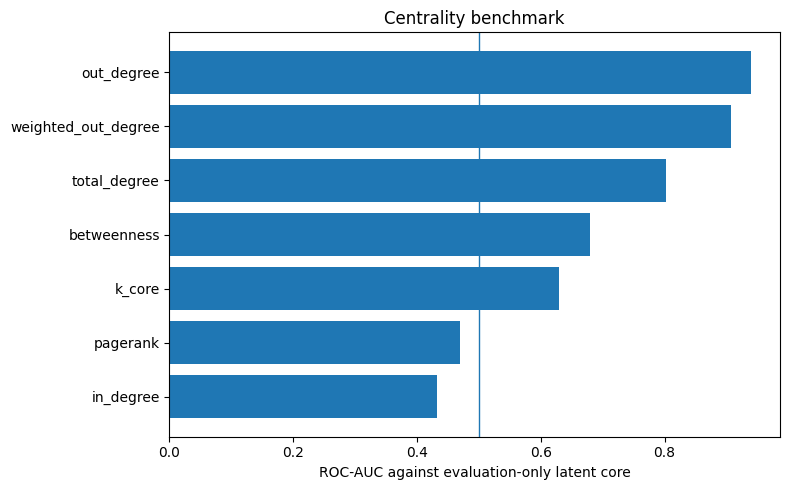

In [6]:
import matplotlib.pyplot as plt

plot_cmp = comparison.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_cmp["method"], plot_cmp["roc_auc"])
ax.axvline(0.5, linewidth=1)
ax.set_xlabel("ROC-AUC against evaluation-only latent core")
ax.set_title("Centrality benchmark")
plt.tight_layout()
plt.savefig("module2_fig2_centrality_auc.png", dpi=160)
plt.show()


## Part D — Missing-edge robustness of the chain-leader label

This robustness test now perturbs the **actual object used by Module 3**:

$$
\text{edge deletion}
\rightarrow
\text{recompute out-degree}
\rightarrow
\text{recompute } is\_chain\_leader
$$

For each deletion level, the notebook reports:

- Jaccard similarity of the top-5% leader set;
- Spearman correlation of out-degree rankings;
- firm-level label flip rate.

The former node-deletion experiment and repeated recomputation of PageRank/betweenness/eigenvector/composite scores are removed.


In [7]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

N_REPS = 100
REMOVE_LEVELS = [0.05, 0.10, 0.20, 0.30]

firms = load_firm_master()
edges = load_supplier_edges()
firm_ids = firms["firm_id"].tolist()

G_full = build_firm_graph(firms, edges)
baseline = pd.DataFrame({
    "firm_id": firm_ids,
    "out_degree": [G_full.out_degree(fid) for fid in firm_ids],
})
baseline = exact_top_pct_flag(
    baseline,
    "out_degree",
    pct=TOP_PCT,
    out_col="is_chain_leader",
).set_index("firm_id")

baseline_set = set(
    baseline.index[baseline["is_chain_leader"] == 1]
)

rows = []
for level in REMOVE_LEVELS:
    jaccards = []
    spearmans = []
    flip_rates = []

    for rep in range(N_REPS):
        subset = random_remove_edges(
            edges,
            remove_frac=level,
            seed=100000 + int(level * 1000) * 1000 + rep,
        )
        G_sub = build_firm_graph(firms, subset)
        perturbed = pd.DataFrame({
            "firm_id": firm_ids,
            "out_degree": [G_sub.out_degree(fid) for fid in firm_ids],
        })
        perturbed = exact_top_pct_flag(
            perturbed,
            "out_degree",
            pct=TOP_PCT,
            out_col="is_chain_leader",
        ).set_index("firm_id")

        perturbed_set = set(
            perturbed.index[perturbed["is_chain_leader"] == 1]
        )
        union = baseline_set | perturbed_set
        jaccards.append(
            len(baseline_set & perturbed_set) / len(union) if union else 1.0
        )

        rho = spearmanr(
            baseline["out_degree"].to_numpy(),
            perturbed.loc[baseline.index, "out_degree"].to_numpy(),
        ).statistic
        spearmans.append(float(rho))

        flips = (
            baseline["is_chain_leader"].to_numpy()
            != perturbed.loc[baseline.index, "is_chain_leader"].to_numpy()
        )
        flip_rates.append(float(flips.mean()))

    rows.append({
        "edge_removal_fraction": level,
        "n_reps": N_REPS,
        "mean_top5_jaccard": np.mean(jaccards),
        "sd_top5_jaccard": np.std(jaccards, ddof=1),
        "mean_out_degree_spearman": np.mean(spearmans),
        "sd_out_degree_spearman": np.std(spearmans, ddof=1),
        "mean_chain_leader_flip_rate": np.mean(flip_rates),
        "sd_chain_leader_flip_rate": np.std(flip_rates, ddof=1),
        "data_type": "SYNTHETIC_CALIBRATED_METHOD_VALIDATION",
    })

robustness = pd.DataFrame(rows)
robustness.to_csv(
    "module2_edge_removal_robustness.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 90)
print("PART D - Missing-edge robustness of out-degree chain-leader label")
print("=" * 90)
print(robustness.round(4).to_string(index=False))
print("\nSaved: module2_edge_removal_robustness.csv")


PART D - Missing-edge robustness of out-degree chain-leader label
 edge_removal_fraction  n_reps  mean_top5_jaccard  sd_top5_jaccard  mean_out_degree_spearman  sd_out_degree_spearman  mean_chain_leader_flip_rate  sd_chain_leader_flip_rate                              data_type
                  0.05     100             0.7607           0.0460                    0.9773                  0.0012                       0.0137                     0.0030 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
                  0.10     100             0.6599           0.0443                    0.9538                  0.0022                       0.0206                     0.0032 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
                  0.20     100             0.5735           0.0517                    0.9041                  0.0043                       0.0272                     0.0042 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
                  0.30     100             0.5024           0.0485                    

### Missing-edge robustness

The curve summarizes how often the binary chain-leader label changes as network edges are removed.


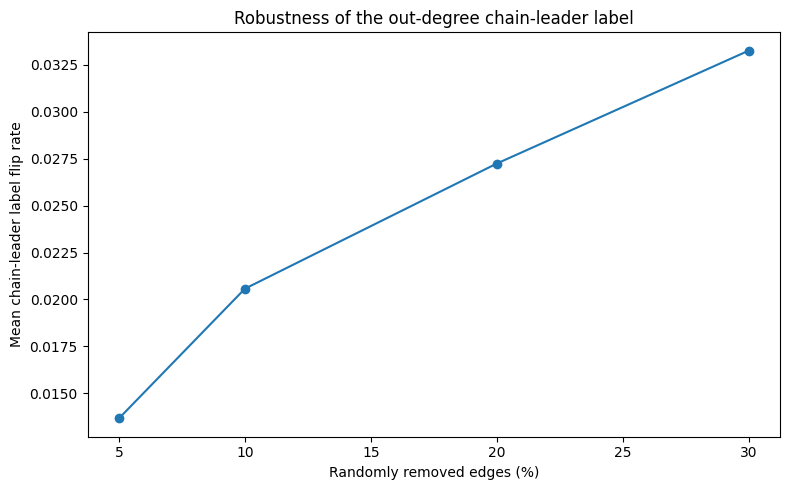

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    robustness["edge_removal_fraction"] * 100,
    robustness["mean_chain_leader_flip_rate"],
    marker="o",
)
ax.set_xlabel("Randomly removed edges (%)")
ax.set_ylabel("Mean chain-leader label flip rate")
ax.set_title("Robustness of the out-degree chain-leader label")
plt.tight_layout()
plt.savefig("module2_fig3_edge_removal_robustness.png", dpi=160)
plt.show()


## Part E — Final Module 2 output for Module 3

Module 3 should receive **only the chain-leader attribute**, not the continuous centrality measures.

Output schema:

- `firm_id`
- `is_chain_leader`

The separate diagnostics file remains available for Module 2 evaluation and figures but is not a predictive-feature interface.


In [9]:
# -*- coding: utf-8 -*-
import pandas as pd

centrality_df = pd.read_csv(
    "module2_firm_centrality_diagnostics.csv",
    encoding="utf-8-sig",
)

final_df = centrality_df[["firm_id", "is_chain_leader"]].copy()
final_df["data_type"] = "SYNTHETIC_CALIBRATED_METHOD_VALIDATION"

assert final_df["firm_id"].nunique() == len(final_df) == 1500
assert final_df["is_chain_leader"].sum() == 75

forbidden = {
    "latent_core_true",
    "latent_core_propensity",
    "pagerank",
    "betweenness",
    "k_core",
    "out_degree",
}
assert forbidden.isdisjoint(final_df.columns)

final_df.to_csv(
    "module2_firm_network_features.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 90)
print("PART E - Final downstream interface")
print("=" * 90)
print(final_df.head().to_string(index=False))
print(f"\nSaved: module2_firm_network_features.csv ({len(final_df)} rows)")
print("Module 3 feature from Module 2: is_chain_leader only.")


PART E - Final downstream interface
  firm_id  is_chain_leader                              data_type
SYNF00001                1 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
SYNF00002                1 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
SYNF00003                0 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
SYNF00004                0 SYNTHETIC_CALIBRATED_METHOD_VALIDATION
SYNF00005                0 SYNTHETIC_CALIBRATED_METHOD_VALIDATION

Saved: module2_firm_network_features.csv (1500 rows)
Module 3 feature from Module 2: is_chain_leader only.
